In [1]:
!pip install quandl

In [2]:
pip install yFinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2023-01-01")

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267952  72.306521  70.568525  70.819223  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [4]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [5]:
df.columns = df.columns.get_level_values(0)

df = df[['Open','High','Low','Close','Volume']]

df['HL_PCT'] = (df['High'] - df['Close']) / df['Close'] * 100
df['pct_change'] = (df['Close'] - df['Open']) / df['Open'] * 100
print(df.head())

Price            Open       High        Low      Close     Volume    HL_PCT  \
Date                                                                          
2020-01-02  71.409785  72.460784  71.156682  72.400520  135480400  0.083236   
2020-01-03  71.629145  72.455958  71.472462  71.696640  146322800  1.059071   
2020-01-06  70.819223  72.306521  70.568525  72.267952  118387200  0.053370   
2020-01-07  72.277571  72.533087  71.708687  71.928047  108872000  0.841174   
2020-01-08  71.631567  73.386438  71.631567  73.085121  132079200  0.412283   

Price       pct_change  
Date                    
2020-01-02    1.387394  
2020-01-03    0.094228  
2020-01-06    2.045672  
2020-01-07   -0.483585  
2020-01-08    2.029209  


In [6]:
import math

df = df[['Close','HL_PCT','pct_change','Volume']]

forecast_col = 'Close'
df.fillna(-99999, inplace=True)

forecast_out = int(math.ceil(0.1*len(df)))

df['label'] = df[forecast_col].shift(-forecast_out)

print(df.head())

Price           Close    HL_PCT  pct_change     Volume      label
Date                                                             
2020-01-02  72.400520  0.083236    1.387394  135480400  66.712929
2020-01-03  71.696640  1.059071    0.094228  146322800  66.454384
2020-01-06  72.267952  0.053370    2.045672  118387200  68.372894
2020-01-07  71.928047  0.841174   -0.483585  108872000  68.421211
2020-01-08  73.085121  0.412283    2.029209  132079200  67.312149


In [7]:
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Remove missing values
df.dropna(inplace=True)

X = df.drop(columns=['label']).values
y = df['label'].values
X = df.drop(columns=['label']).values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
clf = LinearRegression()
clf.fit(X_train,y_train)
accuracy = clf.score(X_test, y_test)
print(accuracy)

0.7172132022913074


[160.50832568 160.44840757 161.78345431 162.20198751 160.7582342
 158.96703902 157.67763666 160.68059998 160.88783457 159.61183695
 158.20157675 155.74342142 155.53547269 152.75568452 154.64990763
 154.87383613 156.1273314  156.82396195 157.48065053 155.31931921
 154.75558606 152.35674457 153.80106674 151.17611184 151.17260992
 148.0289986  149.70723809 151.50768645 153.21131373 153.31447659
 155.48131623 158.09382414 159.34048709 160.28884907 161.10819801
 161.28209207 162.51339828 162.9969509  161.47347258 160.86758854
 163.58607378 163.0873594  159.74366779 160.2649334  159.03829641
 157.75772942 158.13491205 159.48785228 159.07909459 156.84760741
 157.60484292 157.77808501 158.95408084 156.86669363 153.46580086
 153.0071567  152.3884859  153.27883813 154.51007602 149.25441515
 152.50155819 155.69116507 152.57198595 150.87347179 147.77838729
 148.95978634 147.94213323 140.45390538 144.37828694 145.1088215
 146.42889771 144.36638939 139.82804592 138.97895538 141.73472821
 140.9067938

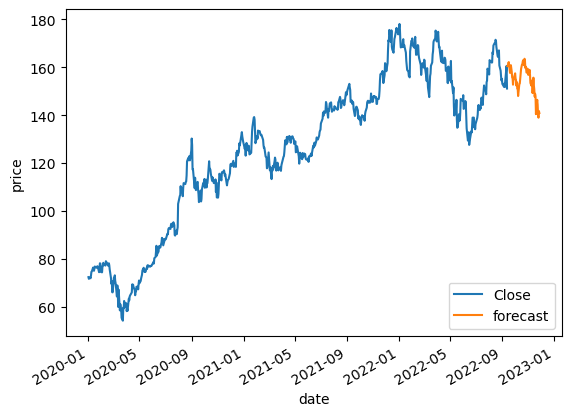

In [8]:
import datetime
import matplotlib.pyplot as plt
from matplotlib import style
X = X[:-forecast_out]
X_lately = X[-forecast_out:]
forecast_set = clf.predict(X_lately)
print(forecast_set, accuracy, forecast_out)
df['forecast'] = np.nan
last_date = df.iloc[-1].name
last_unix = last_date.timestamp()
one_day = 86400
next_unix = last_unix + one_day
for i in forecast_set:
    next_date = datetime.datetime.fromtimestamp(next_unix)
    next_unix += one_day
    df.loc[next_date] = [np.nan for _ in range(len(df.columns)-1)] + [i]

df['Close'].plot()
df['forecast'].plot()
plt.legend(loc=4)
plt.xlabel('date')
plt.ylabel('price')
plt.show()